# Fra hukommelsesforsøg til deltagernes forskelle

Kør cellerne fra toppen med **Run All**. Kræver Python 3 og `pandas` i din Jupyter-kernel.
Notebooken læser de tre JSON-filer i samme mappe og skriver **deltager_forskelle.csv**.
Der er én række per færdig, reel deltager. CSV'en indeholder både grundmål og forskelle,
så hver sammenligning kan efterregnes. Der skrives også en **kolonneforklaring.csv**.

Alle accuracy-mål er andele fra 0 til 1. Forskelle er mellem -1 og 1: 0,20 betyder
20 procentpoint. Tomme CSV-felter er manglende/udelukkede målinger, **ikke nul**.
Originalfilerne ændres ikke. Ingen hypoteseprøver eller konfidensintervaller beregnes her.

## Analysevalg
- Kilder: `supabase_export_anonymized.json`, `quality_assessment.json`, `export_manifest.json` og README.
- Kun protokollen `final-v2.1-draft`, fuldførte sessioner med samtykke og uden testmarkering.
- Kvalitetsflag anvendes separat for hver forsøgsdel. Kendte tabte free-recall-svar indgår ikke som nul.
- Free recall: start = position 1–5, midte = 6–10, slutning = 11–15, som i de gemte scores.
- Primacy = start minus midte; recency = slutning minus midte, inden for samme person og betingelse.
- Serial recall: korrekt bogstav på korrekt position divideret med præsenteret længde.
- Suppression/tapping sammenlignes med samme persons baseline ved **samme længde**.
- Chunking sammenlignes med baseline på ni bogstaver.

Der er én liste per betingelse/længde i dette snapshot. Deltager-ID'er identificerer her
sessioner; ved fremtidige gentagne sessioner per person skal personidentiteten og sammenlægningen afklares.

In [1]:
import json
import math
import re
from pathlib import Path
import pandas as pd

# Virker både med notebookmappen og dens overordnede projektmappe som arbejdsmappe.
DATA_DIR = Path.cwd()
if not (DATA_DIR / "supabase_export_anonymized.json").exists():
    DATA_DIR = DATA_DIR / "human memory experiment"
PROTOCOL = "final-v2.1-draft"

def read_json(name):
    return json.loads((DATA_DIR / name).read_text(encoding="utf-8"))

data = read_json("supabase_export_anonymized.json")
quality = read_json("quality_assessment.json")
manifest = read_json("export_manifest.json")
assert manifest["protocol_version"] == quality["protocol_version"] == PROTOCOL
assert len(data["sessions"]) == manifest["sessions"]
assert len(data["trials"]) == manifest["trials"]
assert sum(s["status"] == "completed" for s in data["sessions"]) == manifest["completed_sessions"]
assert len({s["id"] for s in data["sessions"]}) == len(data["sessions"])
assert len({t["id"] for t in data["trials"]}) == len(data["trials"])
assert len({q["session_id"] for q in quality["sessions"]}) == len(quality["sessions"])
q_by_id = {q["session_id"]: q for q in quality["sessions"]}
assert set(q_by_id) == {s["id"] for s in data["sessions"]}
assert all(t["session_id"] in q_by_id for t in data["trials"])

participants = [s for s in data["sessions"]
                if s["protocol_version"] == PROTOCOL
                and s["status"] == "completed" and s["consent_given"]
                and not q_by_id[s["id"]]["is_test_session"]]
assert len({s["participant_code"] for s in participants}) == len(participants)
print(f"Indlæst {len(data['sessions'])} sessioner og {len(data['trials'])} trials.")
print(f"{len(participants)} færdige, reelle deltagere indgår i CSV'en.")

Indlæst 28 sessioner og 220 trials.
17 færdige, reelle deltagere indgår i CSV'en.


## Kontrol af grundmål
Vi kontrollerer de mål, der faktisk bruges i forskellene: free-recall-træffere og
positionsgrupper samt serial-recall-positionstræffere. Kontrollen anvender de gemte
normaliserede svar; der udføres ingen ny stavekorrektion eller ændring af svar.
De oprindelige scoringsfunktioner er ikke med i denne mappe, så dette er en selvstændig
kontrol af hovedmålene, ikke en fuld genskabelse af appens fejltaksonomi.
Notebooken stopper ved uventede dubletter, manglende brugbare trials eller afvigende scores.

In [2]:
SECTIONS = ["free_recall", "serial_baseline", "articulatory_suppression", "finger_tapping", "chunking"]
FREE = ["baseline", "fast", "pause", "working_memory"]
EXPECTED = {1: "baseline", 2: "fast", 3: "pause", 4: "working_memory",
            5: "baseline_6", 6: "baseline_7", 7: "baseline_8", 8: "baseline_9",
            9: "articulatory_suppression", 10: "finger_tapping", 11: "grouped"}

def section(t):
    n = t["trial_number"]
    return ("free_recall" if n <= 4 else "serial_baseline" if n <= 8 else
            "articulatory_suppression" if n == 9 else "finger_tapping" if n == 10 else "chunking")

def check_close(a, b):
    assert math.isclose(a, b, abs_tol=1e-10), (a, b)

trial_by_session = {}
checked = 0
for s in participants:
    sid = s["id"]
    q = q_by_id[sid]
    assert q["participant_id"] == s["participant_code"]
    trials = [t for t in data["trials"] if t["session_id"] == sid and t["completed"]]
    assert len({t["trial_number"] for t in trials}) == len(trials), "Dubleret trialnummer"
    by_condition = {}
    for t in trials:
        assert EXPECTED[t["trial_number"]] == t["condition"]
        if not q["usable"][section(t)]:
            continue
        score = t["score"]
        if section(t) == "free_recall":
            assert t["experiment_type"] == "free_recall"
            seq = [w.casefold() for w in t["presented_sequence"]]
            assert len(seq) == len(set(seq)) == 15
            words = set(re.findall(r"[^\W_]+", t["normalized_response"].casefold()))
            hits = [int(w in words) for w in seq]
            assert sum(hits) == score["recalled_count"]
            assert score["total_words"] == 15
            check_close(sum(hits) / 15, score["accuracy"])
            for name, start in [("primacy", 0), ("middle", 5), ("recency", 10)]:
                g = score["position_groups"][name]
                assert g["total"] == 5 and g["recalled"] == sum(hits[start:start+5])
                check_close(g["accuracy"], sum(hits[start:start+5]) / 5)
        else:
            assert t["experiment_type"] == "serial_recall"
            seq = t["presented_sequence"]
            response = t["normalized_response"]
            assert isinstance(seq, str) and isinstance(response, str)
            matches = sum(a == b for a, b in zip(seq, response))
            assert score["presented_length"] == len(seq)
            assert matches == score["positional_matches"]
            check_close(matches / len(seq), score["positional_accuracy"])
        by_condition[t["condition"]] = t
        checked += 1
    for n, condition in EXPECTED.items():
        if q["usable"][section({"trial_number": n})]:
            assert condition in by_condition, (s["participant_code"], condition)
    trial_by_session[sid] = by_condition

print(f"Kontrolleret hovedscores i {checked} brugbare trials.")

Kontrolleret hovedscores i 176 brugbare trials.


## Grundmål per deltager
Kolonnenavne er på engelsk for at være lette at bruge i Python. Kolonneforklaringen er
på dansk. Kvalitetsflag og eksklusionsårsager følger med hver række.

In [3]:
rows = []
descriptions = {"participant_id": ("Anonym deltager-ID", "id"),
                "exclusion_reasons": ("Kildens årsager til udelukkelse af forsøgsdele", "tekst")}

def put(row, name, value, description, unit="andel"):
    row[name] = value
    descriptions[name] = (description, unit)

for s in participants:
    q = q_by_id[s["id"]]
    trials = trial_by_session[s["id"]]
    row = {"participant_id": s["participant_code"],
           "exclusion_reasons": "; ".join(q["exclusion_reasons"])}
    for sec in SECTIONS:
        put(row, f"usable_{sec}", q["usable"][sec], f"Kvalitetsflag for {sec}", "bool")
    for condition in FREE:
        t = trials.get(condition)
        score = t["score"] if t else None
        put(row, f"free_{condition}_accuracy", score["accuracy"] if score else None,
            f"Samlet andel korrekt i free recall: {condition}")
        for group in ["primacy", "middle", "recency"]:
            put(row, f"free_{condition}_{group}_accuracy",
                score["position_groups"][group]["accuracy"] if score else None,
                f"Andel korrekt i positionsgruppen {group}, betingelse {condition}")
    for condition in ["baseline_6", "baseline_7", "baseline_8", "baseline_9",
                      "articulatory_suppression", "finger_tapping", "grouped"]:
        t = trials.get(condition)
        score = t["score"] if t else None
        put(row, f"serial_{condition}_accuracy", score["positional_accuracy"] if score else None,
            f"Andel bogstaver på korrekt position: {condition}")
        put(row, f"serial_{condition}_length", score["presented_length"] if score else None,
            f"Præsenteret sekvenslængde: {condition}", "antal bogstaver")
    for task in ["articulatory_suppression", "finger_tapping"]:
        length = row[f"serial_{task}_length"]
        baseline = trials.get(f"baseline_{length}") if length is not None else None
        if length is not None:
            assert length in [6, 7, 8, 9]
        put(row, f"serial_{task}_matched_baseline_accuracy",
            baseline["score"]["positional_accuracy"] if baseline else None,
            f"Samme persons baseline ved samme længde som {task}")
    if "grouped" in trials:
        assert trials["grouped"]["score"]["presented_length"] == 9
    rows.append(row)

participant_df = pd.DataFrame(rows).sort_values("participant_id").reset_index(drop=True)
print(participant_df[["participant_id"] + [f"usable_{s}" for s in SECTIONS]].to_string(index=False))

participant_id  usable_free_recall  usable_serial_baseline  usable_articulatory_suppression  usable_finger_tapping  usable_chunking
          P006                True                    True                             True                   True             True
          P007               False                    True                            False                  False             True
          P009               False                    True                             True                   True             True
          P012                True                    True                             True                   True             True
          P013                True                    True                             True                   True             True
          P014                True                    True                             True                   True             True
          P015                True                    True                  

## Forskellene, som I kan lave statistik på
Alle effektkolonner slutter med `_diff`. Positiv betyder altid **første mål minus andet mål**.
For primacy/recency betyder positiv en fordel over midten. For suppression betyder en
negativ forskel dårligere recall end baseline. Hver forskel kræver begge mål fra samme deltager.

Ændringen i recency efter interferens er en *forskel mellem forskelle*:
`(slutning − midte) med interferens − (slutning − midte) ved baseline`.

In [4]:
effect_columns = []

def difference(name, a, b):
    participant_df[name] = participant_df[a] - participant_df[b]
    descriptions[name] = (f"{a} minus {b}", "andelsforskel; gang med 100 for procentpoint")
    effect_columns.append(name)

for condition in FREE:
    for effect in ["primacy", "recency"]:
        difference(f"free_{condition}_{effect}_diff",
                   f"free_{condition}_{effect}_accuracy", f"free_{condition}_middle_accuracy")

for condition in ["fast", "pause", "working_memory"]:
    for effect in ["primacy", "recency"]:
        difference(f"free_{condition}_vs_baseline_{effect}_diff",
                   f"free_{condition}_{effect}_diff", f"free_baseline_{effect}_diff")
    difference(f"free_{condition}_vs_baseline_accuracy_diff",
               f"free_{condition}_accuracy", "free_baseline_accuracy")

for effect in ["primacy", "recency"]:
    difference(f"free_working_memory_vs_pause_{effect}_diff",
               f"free_working_memory_{effect}_diff", f"free_pause_{effect}_diff")
difference("free_working_memory_vs_pause_accuracy_diff", "free_working_memory_accuracy", "free_pause_accuracy")

for task in ["articulatory_suppression", "finger_tapping"]:
    difference(f"serial_{task}_vs_matched_baseline_diff",
               f"serial_{task}_accuracy", f"serial_{task}_matched_baseline_accuracy")
difference("serial_chunking_vs_baseline9_diff", "serial_grouped_accuracy", "serial_baseline_9_accuracy")
difference("serial_baseline9_vs_baseline6_diff", "serial_baseline_9_accuracy", "serial_baseline_6_accuracy")

# Direkte sammenligning kræver samme sekvenslængde i de to sekundære opgaver.
both = participant_df["serial_articulatory_suppression_length"].notna() & participant_df["serial_finger_tapping_length"].notna()
assert (participant_df.loc[both, "serial_articulatory_suppression_length"] ==
        participant_df.loc[both, "serial_finger_tapping_length"]).all()
difference("serial_suppression_vs_tapping_diff", "serial_articulatory_suppression_accuracy", "serial_finger_tapping_accuracy")

display(participant_df[["participant_id", "free_baseline_middle_accuracy",
                        "free_baseline_recency_accuracy", "free_baseline_recency_diff",
                        "serial_chunking_vs_baseline9_diff"]])

,participant_id,free_baseline_middle_accuracy,free_baseline_recency_accuracy,free_baseline_recency_diff,serial_chunking_vs_baseline9_diff
0,P006,0.4,0.6,0.2,0.666667
1,P007,NaN,NaN,NaN,0.333333
2,P009,NaN,NaN,NaN,0.888889
3,P012,0.6,0.6,0.0,0.333333
4,P013,0.0,0.6,0.6,0.111111
5,P014,0.2,0.4,0.2,0.777778
6,P015,0.2,0.4,0.2,0.000000
7,P016,0.0,0.4,0.4,0.333333
8,P018,0.0,0.0,0.0,0.666667
9,P020,0.4,0.2,-0.2,0.000000


## Gem CSV og kontroller resultatet
CSV bruger komma som separator, punktum som decimaltegn og UTF-8 med BOM.
I dansk Excel kan filen importeres via **Data → Fra tekst/CSV**; vælg komma som separator.
Notebooken overskriver de to afledte CSV-filer ved genkørsel.

In [5]:
# Effekterne står først; deres grundmål og kvalitetsflag følger bagefter.
columns = ["participant_id"] + effect_columns
columns += [c for c in participant_df.columns if c not in columns]
participant_df = participant_df[columns]
dictionary_df = pd.DataFrame([
    {"column": c, "description": descriptions[c][0], "unit": descriptions[c][1]}
    for c in columns
])
output_path = DATA_DIR / "deltager_forskelle.csv"
participant_df.to_csv(output_path, index=False, encoding="utf-8-sig", na_rep="")
dictionary_df.to_csv(DATA_DIR / "kolonneforklaring.csv", index=False, encoding="utf-8-sig")

# Kontroller også den faktisk gemte fil.
reloaded = pd.read_csv(output_path, encoding="utf-8-sig", keep_default_na=True)
pd.testing.assert_frame_equal(participant_df[effect_columns], reloaded[effect_columns], check_dtype=False)
assert len(reloaded) == len(participants)
for sec in SECTIONS:
    print(f"{sec}: {int(participant_df[f'usable_{sec}'].sum())} brugbare deltagere")
print(f"Gemt {len(participant_df)} rækker og {len(columns)} kolonner i {output_path.name}.")

free_recall: 15 brugbare deltagere
serial_baseline: 17 brugbare deltagere
articulatory_suppression: 16 brugbare deltagere
finger_tapping: 15 brugbare deltagere
chunking: 17 brugbare deltagere
Gemt 17 rækker og 64 kolonner i deltager_forskelle.csv.


## Eksempel: gennemsnit af deltagernes recency-effekt
Der tages ét tal per deltager, og kun manglende værdier i den valgte effekt udelades.
Undgå `dropna()` på hele CSV'en: det ville også fjerne deltagere, som kun mangler en anden forsøgsdel.
Tabellen nedenfor er beskrivende; den konkluderer ikke statistisk signifikans.

In [6]:
values = participant_df["free_baseline_recency_diff"].dropna()
print(f"Baseline recency: n = {values.count()}")
print(f"Gennemsnitlig forskel: {values.mean():.3f} = {100 * values.mean():.1f} procentpoint")

# Samme fremgangsmåde for alle effekter. Standardafvigelse mellem deltagere (ddof=1).
summary = participant_df[effect_columns].agg(["count", "mean", "std"]).T
summary.columns = ["n_deltagere", "gennemsnitlig_forskel", "standardafvigelse"]
display(summary)

Baseline recency: n = 15
Gennemsnitlig forskel: 0.240 = 24.0 procentpoint


,n_deltagere,gennemsnitlig_forskel,standardafvigelse
free_baseline_primacy_diff,15.0,0.413333,0.266905
free_baseline_recency_diff,15.0,0.240000,0.229285
free_fast_primacy_diff,15.0,0.106667,0.249189
free_fast_recency_diff,15.0,0.386667,0.206559
free_pause_primacy_diff,15.0,0.093333,0.361478
free_pause_recency_diff,15.0,-0.026667,0.361478
free_working_memory_primacy_diff,15.0,0.133333,0.390360
free_working_memory_recency_diff,15.0,-0.066667,0.326599
free_fast_vs_baseline_primacy_diff,15.0,-0.306667,0.260403
free_fast_vs_baseline_recency_diff,15.0,0.146667,0.306749


## Begrænsninger, som følger af forsøgsdesignet
- Der er kun én liste per betingelse/længde, og rækkefølgen er fast. Forskelle kan derfor også
  påvirkes af specifikke lister, øvelse og træthed.
- Længden i suppression/tapping er valgt ud fra baselinepræstation. Sammenligning ved samme
  længde er relevant, men den datastyrede udvælgelse kan påvirke forskellen (selektion/regression mod gennemsnittet).
- Chunking ændrer både meningsfuldhed og præsentation: eksemplet i data viser tre ord vist
  som enheder i stedet for ni enkeltbogstaver, og den samlede eksponeringstid er forskellig.
  `serial_chunking_vs_baseline9_diff` er derfor forskellen mellem de samlede betingelser.
- Baseline ved 6–9 bogstaver giver en præstationskurve, ikke et præcist estimat af en persons memory span.
- Intervaller for gruppens gennemsnit skal bruge antallet af deltagere med den pågældende forskel.
  Et interval, der omfatter nul, dokumenterer ikke, at finger tapping ingen effekt har.

## Baseline: recall for ordposition 1–15
Grafen viser andelen af brugbare deltagere, der huskede ordet på hver position.
Hvert punkt bygger på ét binært svar per deltager (husket = 1, ikke husket = 0).
Ordidentiteten varierer mellem deltagere. Linjen forbinder observerede gennemsnit;
den er ikke en tilpasset trendkurve. Ingen glatning eller udvælgelse af positioner.

Skyggen viser punktvise 95 % Wilson-intervaller for andelene. De er ikke simultane
intervaller for hele kurven og tester ikke primacy/recency-forskellene. Brug deltagernes
`free_baseline_primacy_diff` og `free_baseline_recency_diff` til disse sammenligninger.

Kræver også `matplotlib`. Figuren gemmes som PNG og SVG i datamappen.


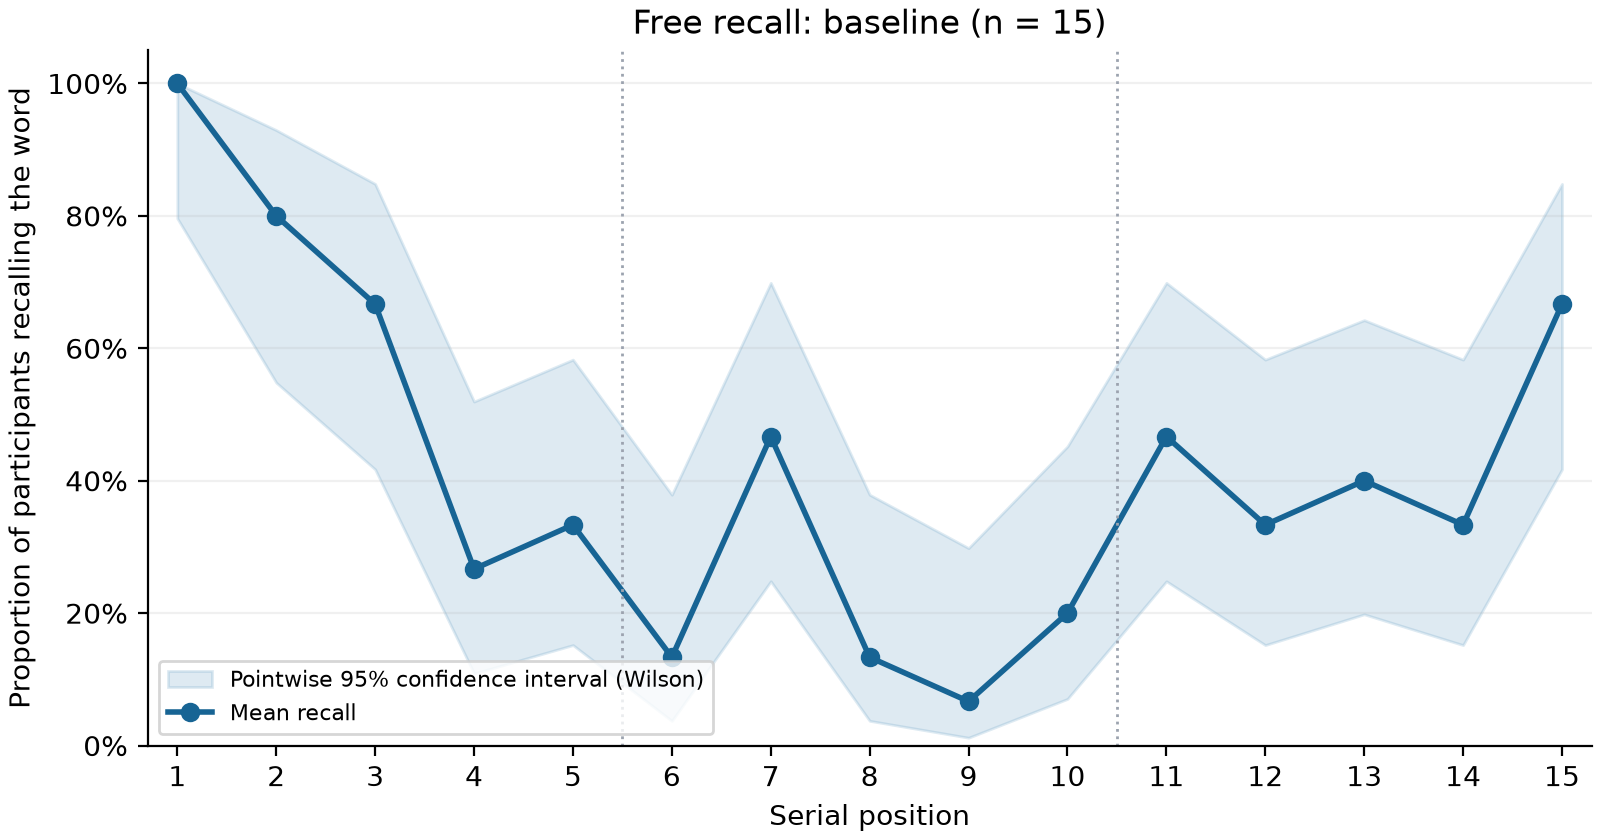

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

position_rows = []
for s in participants:
    trial = trial_by_session[s["id"]].get("baseline")
    if trial is None:
        continue
    recalled = set(w.casefold() for w in trial["score"]["recalled_words"])
    position_rows.append([int(w.casefold() in recalled) for w in trial["presented_sequence"]])

position_data = pd.DataFrame(position_rows, columns=range(1, 16))
n_position = len(position_data)
assert n_position > 0
assert n_position == participant_df["free_baseline_recency_diff"].count()
means = position_data.mean()
# Kontroller at positionsgraf og de allerede beregnede gruppemål stemmer overens.
check_close(means.loc[11:15].mean() - means.loc[6:10].mean(),
            participant_df["free_baseline_recency_diff"].mean())

z = 1.959963984540054
centre = (means + z*z / (2*n_position)) / (1 + z*z/n_position)
half = z * ((means*(1-means)/n_position + z*z/(4*n_position*n_position))**0.5) / (1+z*z/n_position)

fig, ax = plt.subplots(figsize=(8, 4.2), layout="constrained")
ax.fill_between(means.index, centre-half, centre+half, color="#2376ab", alpha=0.15,
                label="Pointwise 95% confidence interval (Wilson)")
ax.plot(means.index, means.values, "o-", color="#176494", linewidth=2,
        label="Mean recall")
for boundary in [5.5, 10.5]:
    ax.axvline(boundary, color="#9ca3af", linestyle=":", linewidth=1)
ax.set(xlabel="Serial position", ylabel="Proportion of participants recalling the word",
       title=f"Free recall: baseline (n = {n_position})", xlim=(0.7, 15.3), ylim=(0, 1.05))
ax.set_xticks(range(1,16))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.18)
ax.legend(loc="lower left", fontsize=8)
fig.savefig(DATA_DIR / "baseline_recall_position.png", dpi=200)
fig.savefig(DATA_DIR / "baseline_recall_position.svg")
plt.show()
